### 조건에 따른 파생변수 생성하기

#### 자동차 연비 데이터(mpg.csv) mile per gallon

1. 제조사(manufacturer)
2. 모델명(model)
3. 배기량(displ, displacement)
4. 생산연도(year)
5. 실린더수(cyl, cylinders)
6. 변속기(trans)
7. 구동방식(drive, 전륜, 후륜, 4륜)
8. 도시연비(cty, city)
9. 고속도로연비(hwy, highway)
10. 연료종류(fl, fuel)
11. 자동차종류(category, class)


#### 연비 평균을 기준으로 합격 여부 판정 및 통계 구하기

- A. 연비 평균(avg) 구하기 (도시연비, 고속도로연비)
- B. 합격판정 컬럼 생성(test) : 평균값을 기준으로 이상이면 pass, 아니면 fail 값을 할당(numpy.where)
- C. 합격 빈도 생성(df.value_counts())
- D. 시각화(막대그래프, plot.bar)

In [1]:
import pandas as pd
df = pd.read_csv('mpg.csv', header=0)
print(df)

    manufacturer   model  displ  year  cyl       trans drv  cty  hwy fl  \
0           audi      a4    1.8  1999    4    auto(l5)   f   18   29  p   
1           audi      a4    1.8  1999    4  manual(m5)   f   21   29  p   
2           audi      a4    2.0  2008    4  manual(m6)   f   20   31  p   
3           audi      a4    2.0  2008    4    auto(av)   f   21   30  p   
4           audi      a4    2.8  1999    6    auto(l5)   f   16   26  p   
..           ...     ...    ...   ...  ...         ...  ..  ...  ... ..   
229   volkswagen  passat    2.0  2008    4    auto(s6)   f   19   28  p   
230   volkswagen  passat    2.0  2008    4  manual(m6)   f   21   29  p   
231   volkswagen  passat    2.8  1999    6    auto(l5)   f   16   26  p   
232   volkswagen  passat    2.8  1999    6  manual(m5)   f   18   26  p   
233   volkswagen  passat    3.6  2008    6    auto(s6)   f   17   26  p   

    category  
0    compact  
1    compact  
2    compact  
3    compact  
4    compact  
..       

A. 연비 평균(avg) 구하기 (도시연비, 고속도로연비)

In [ ]:
df['avg'] = (df['cty'] + df['hwy']) / 2 # cty와 hwy 열의 평균을 구하여 avg 열에 저장한다.
print(df.head(3)) # avg 열이 추가된 것을 확인
df.describe() # avg 열의 통계량을 확인한다.

  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl category  \
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact   
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact   
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact   
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact   
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact   

    avg  
0  23.5  
1  25.0  
2  25.5  
3  25.5  
4  21.0  


,displ,year,cyl,cty,hwy,avg
count,234.000000,234.000000,234.000000,234.000000,234.000000,234.000000
mean,3.471795,2003.500000,5.888889,16.858974,23.440171,20.149573
std,1.291959,4.509646,1.611534,4.255946,5.954643,5.050290
min,1.600000,1999.000000,4.000000,9.000000,12.000000,10.500000
25%,2.400000,1999.000000,4.000000,14.000000,18.000000,15.500000
50%,3.300000,2003.500000,6.000000,17.000000,24.000000,20.500000
75%,4.600000,2008.000000,8.000000,19.000000,27.000000,23.500000
max,7.000000,2008.000000,8.000000,35.000000,44.000000,39.500000


B. 합격판정 컬럼 생성(test) : 평균값을 기준으로 이상이면 pass, 아니면 fail 값을 할당(numpy.where)

In [5]:
import numpy as np
df['test'] = np.where(df['avg'] >= 20, 'pass', 'fail') # avg 열의 값이 20 이상이면 'pass', 그렇지 않으면 'fail'을 test 열에 저장한다.
print(df.head()) # test 열이 추가된 것을 확인

  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl category  \
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact   
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact   
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact   
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact   
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact   

    avg  test  
0  23.5  pass  
1  25.0  pass  
2  25.5  pass  
3  25.5  pass  
4  21.0  pass  


C. 합격 빈도 생성(df.value_counts())

In [ ]:
print(df['test'].value_counts())

test
pass    128
fail    106
Name: count, dtype: int64


D. 시각화(막대그래프, plot.bar)

test
pass    128
fail    106
Name: count, dtype: int64


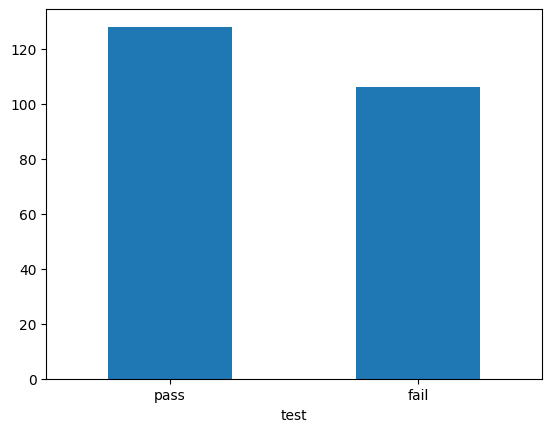

In [9]:
import matplotlib.pyplot as plt
count_test = df['test'].value_counts()
print(count_test)
count_test.plot.bar(x='column1', y='column2', rot=0, stacked=False)
plt.show()

연비 평균을 기준으로 자동차 연비 등급 표시(A, B, C)
- 연비 등급 컬럼 생성(grade) : 평균값이 30 이상이면 A, 20 이상이면 B, 그렇지 않으면 C를 할당(numpy.where)

In [10]:
import numpy as np
df['grade'] = np.where(df['avg'] >= 30, 'A', np.where(df['avg'] >= 20, 'B', 'C'))
print(df.head())

  manufacturer model  displ  year  cyl       trans drv  cty  hwy fl category  \
0         audi    a4    1.8  1999    4    auto(l5)   f   18   29  p  compact   
1         audi    a4    1.8  1999    4  manual(m5)   f   21   29  p  compact   
2         audi    a4    2.0  2008    4  manual(m6)   f   20   31  p  compact   
3         audi    a4    2.0  2008    4    auto(av)   f   21   30  p  compact   
4         audi    a4    2.8  1999    6    auto(l5)   f   16   26  p  compact   

    avg  test grade  
0  23.5  pass     B  
1  25.0  pass     B  
2  25.5  pass     B  
3  25.5  pass     B  
4  21.0  pass     B  


In [ ]:
print(df['grade'].value_counts())
# A, B, C 순서로 정렬 처리
print(df['grade'].value_counts().sort_index())

grade
B    118
C    106
A     10
Name: count, dtype: int64
grade
A     10
B    118
C    106
Name: count, dtype: int64


grade
A     10
B    118
C    106
Name: count, dtype: int64


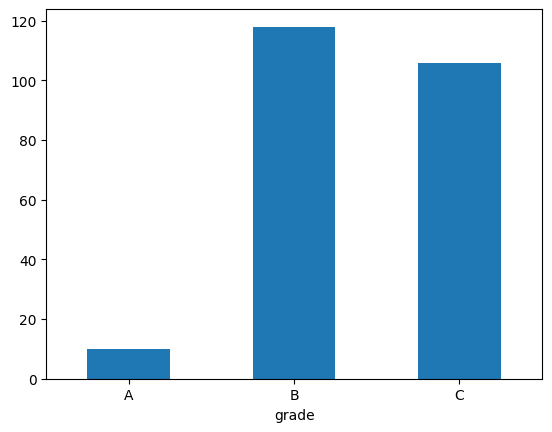

In [16]:
import matplotlib.pyplot as plt
count_grade = df['grade'].value_counts().sort_index()
print(count_grade)
count_grade.plot.bar(x='column1', y='column2', rot=0, stacked=False)
plt.show()